In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

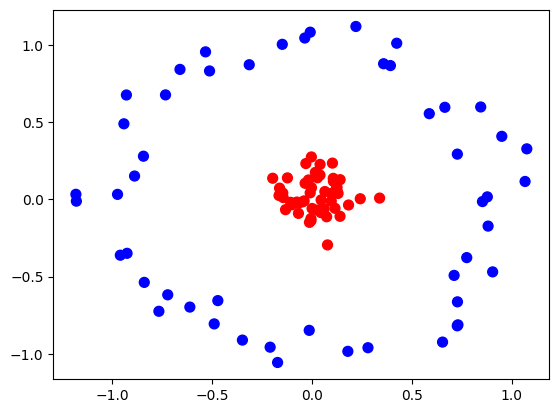

In [3]:

from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [5]:

classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [6]:

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.65

In [7]:

zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\03-11-24\AppData\Local\Temp\ipykernel_9792\2475872515.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


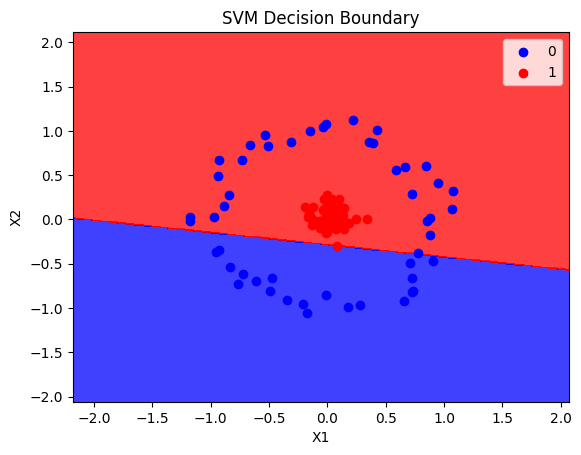

In [8]:

plot_decision_boundary(X, y, classifier)

In [9]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

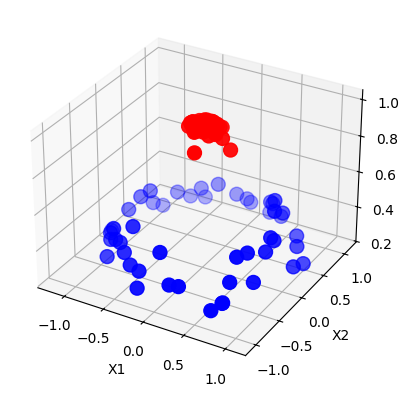

In [10]:

plot_3d_plot(X,y)

In [11]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [12]:

accuracy_score(y_test, y_pred)

1.0

C:\Users\03-11-24\AppData\Local\Temp\ipykernel_9792\2475872515.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


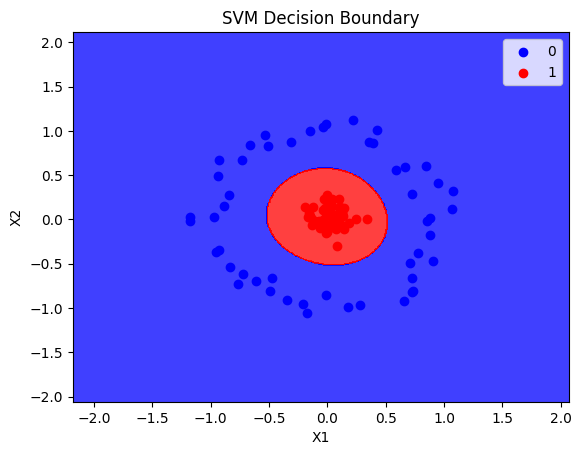

In [13]:

plot_decision_boundary(X, y, rbf_classifier)

In [14]:

poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [15]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\03-11-24\AppData\Local\Temp\ipykernel_9792\2475872515.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


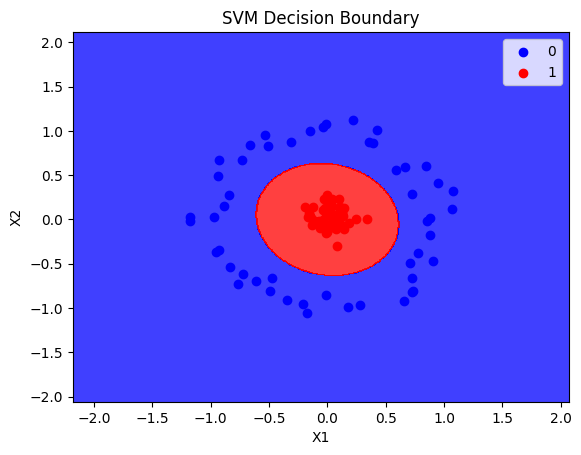

In [16]:

plot_decision_boundary(X, y, poly_classifier)

In [17]:
X

array([[-0.01276748, -0.8483528 ],
       [-0.65934235,  0.84092152],
       [ 0.87816401,  0.01572037],
       [ 0.65421598, -0.92430761],
       [-0.76490632, -0.72494948],
       [-0.01634825,  0.12523752],
       [-1.18006314,  0.03243904],
       [-0.53153183,  0.95446055],
       [ 0.35934037,  0.87753424],
       [ 0.04138213,  0.22592019],
       [-0.34699462, -0.91142495],
       [ 0.18044228, -0.98419985],
       [ 1.0756879 ,  0.32661913],
       [-0.14505168,  0.04056513],
       [-0.13128753, -0.06708787],
       [ 0.10339535,  0.23436785],
       [ 0.71203836, -0.49260481],
       [-0.83798952, -0.53783102],
       [ 0.88205838, -0.17350745],
       [-0.48810459, -0.80653867],
       [-0.92414788, -0.34963454],
       [-0.19551822,  0.1363796 ],
       [-0.00206494,  0.27420918],
       [ 0.06186667, -0.06158349],
       [ 0.14135275, -0.1099756 ],
       [-0.04587441, -0.01648284],
       [ 0.33932956,  0.00789432],
       [-0.12167667,  0.13859036],
       [ 0.39339436,

In [18]:

np.exp(-(X**2)).sum(1)

array([1.4867341 , 1.14048581, 1.46222362, 1.07737439, 1.14828943,
       1.98417069, 1.24738948, 1.15600091, 1.34184601, 1.94852971,
       1.32230722, 1.34756033, 1.21320841, 1.97753563, 1.97842061,
       1.93591937, 1.3868392 , 1.24429676, 1.42965515, 1.30979115,
       1.31061984, 1.94406658, 1.92756234, 1.99239449, 1.9681959 ,
       1.9976261 , 1.89117499, 1.96627984, 1.32929762, 1.97996186,
       1.25191997, 1.27732986, 1.99843651, 1.05696241, 1.43321855,
       1.98454777, 1.30394203, 1.99780231, 1.32133418, 1.96410109,
       1.48210582, 1.94696464, 1.99416757, 1.96984662, 1.97289291,
       1.23848535, 1.97786492, 1.41718336, 1.98821503, 1.27129006,
       1.30701444, 1.98139632, 1.98852251, 1.9796316 , 1.33493009,
       1.24292203, 1.96917639, 1.27678204, 1.21870655, 1.97903739,
       1.98143946, 1.98325677, 1.98101662, 1.45227029, 1.18921599,
       1.9943292 , 1.35747896, 1.19515073, 1.99319086, 1.97407829,
       1.44328312, 1.50647377, 1.4154717 , 1.94283542, 1.99043

In [19]:

X_new=np.exp(-(X**2))

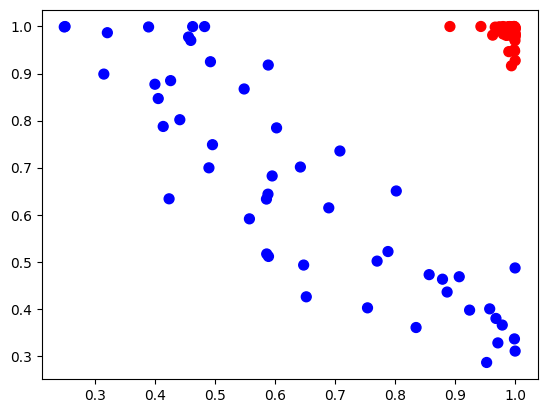

In [20]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')